In [1]:
import pandas as pd
import numpy as np
from utils import preprocess, models
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data/1082-Device-Data-Fix.csv")
df = preprocess.get_clean_df(df)
df = preprocess.create_standarized_gradients(df)
df = preprocess.create_steps_from_irrigation(df)

In [3]:
THRESH_DOWN = -0.1
THRESH_UP = 0.1

plain_model = models.get_plain_predictor()

plain_dates = preprocess.get_plains_dates(df, THRESH_DOWN, THRESH_UP)
df["plain"] = False
df.loc[df["date"].isin(plain_dates), "plain"] = True
df_decay = preprocess.get_dataset_from_df(df, THRESH_UP)

X = preprocess.get_inputs_plain_predictor(df_decay)
df_decay["plain"] = plain_model.predict(X)
df_decay["plain"] = df_decay["plain"].astype(bool)

X.head()

,soil_moisture_40,steps_from_peak,season_autumn,season_spring,season_summer,season_winter,hour_s,hour_c
0,0.277,0,False,False,False,True,0.000000e+00,1.0
1,0.277,1,False,False,False,True,-2.449294e-16,1.0
2,0.277,2,False,False,False,True,-2.449294e-16,1.0
3,0.277,3,False,False,False,True,-4.898587e-16,1.0
4,0.277,4,False,False,False,True,-4.898587e-16,1.0


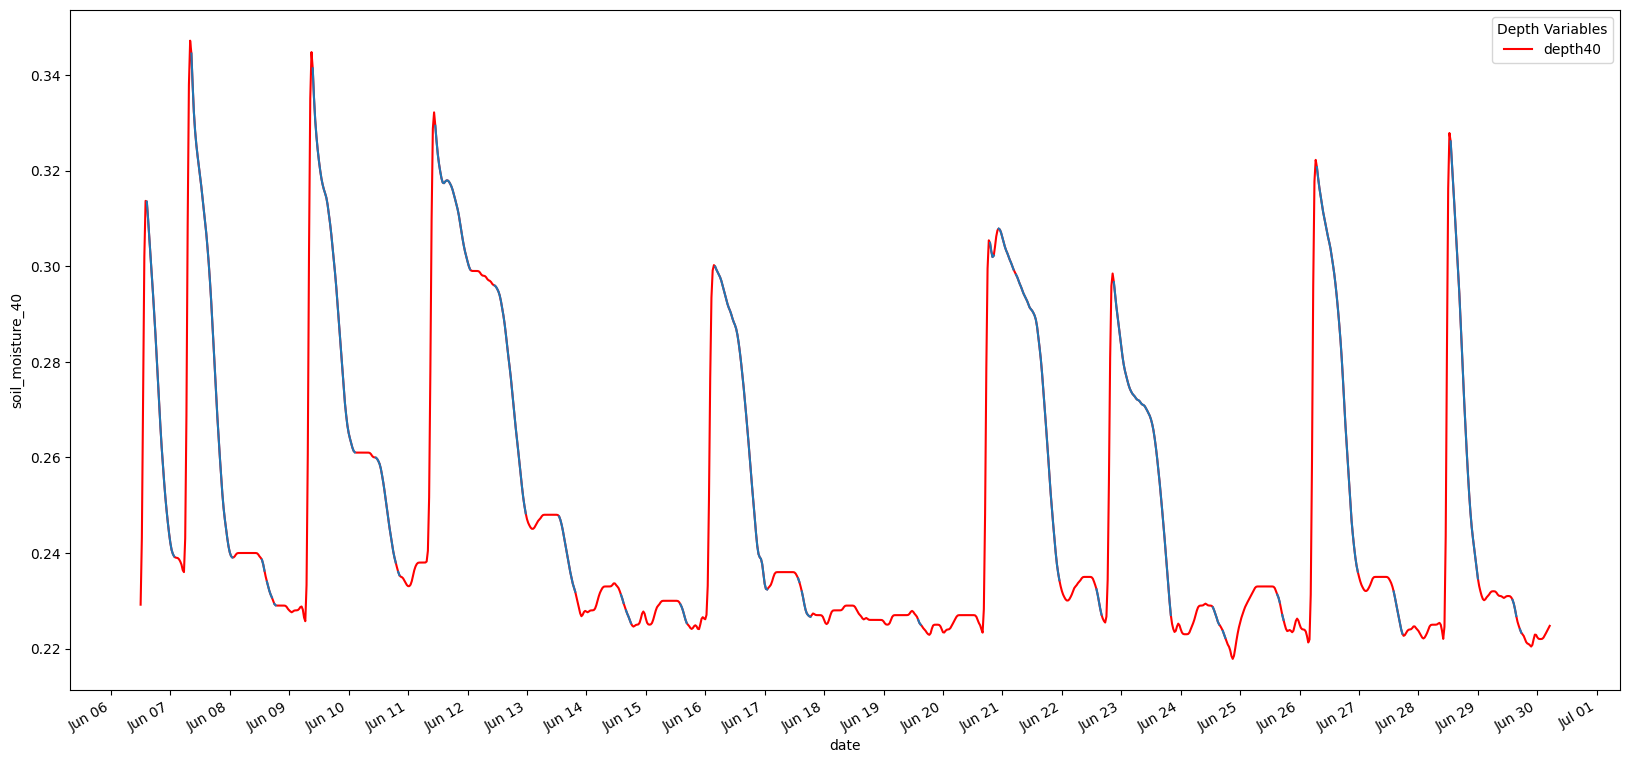

In [4]:
start_date = pd.to_datetime("2024-06-06 12:00:00")
end_date   = pd.to_datetime("2024-06-30 05:00:00")
df_constricted = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
#We use the gradients to detect slopes and plains, but we first normalize to be able to get good scales for thresholding

restricted_mask = ~df_decay["plain"] & ~df_decay["up"]
restricted_dates = df_decay.loc[restricted_mask, "date"]

restricted_df = df_constricted.copy()
restricted_df["soil_moisture_40"] = np.nan
restricted_df["soil_moisture_40"] = df_constricted.loc[df_constricted["date"].isin(restricted_dates), "soil_moisture_40"]

plt.figure(figsize=(20, 10))

sns.lineplot(df_constricted, x="date", y="soil_moisture_40", label="depth40", color="red")
plt.plot(restricted_df["date"], np.ma.masked_invalid(restricted_df["soil_moisture_40"].astype(float)))
# sns.lineplot(plain_df, x="date", y="soil_moisture_40", label="plain", color="blue")
plt.legend(title="Depth Variables")
# plt.ylim(0, 0.40)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()  # rotate labels for clarity
plt.show()
plt.show()

In [5]:
df_decay_grouped = preprocess.separate_slopes_by_groups(df_decay)
df_decay_grouped = preprocess.compute_group_slopes(df_decay_grouped)
X, y = preprocess.compute_slopes_dataset(df_decay_grouped)
X.head()

c:\Users\aleix\OneDrive\Escritorio\SAF\utils\preprocess.py:279: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.0007343901999730224' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_decay_grouped.loc[df_decay_grouped["group"] == i, "slope"] = m
c:\Users\aleix\OneDrive\Escritorio\SAF\utils\preprocess.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_three_per_group = df_slopes.groupby('group').apply(lambda x: x.iloc[:3]).reset_index(drop=True).copy()


,moisture_1,moisture_2,moisture_3,season_autumn,season_spring,season_summer,season_winter,hour_s,hour_c
0,0.342707,0.335025,0.329756,False,True,False,False,-4.898587e-16,1.0
1,0.343507,0.336263,0.331590,False,True,False,False,-3.429011e-15,1.0
2,0.353083,0.343245,0.336434,False,True,False,False,-1.077937e-14,1.0
3,0.348276,0.339413,0.333123,False,True,False,False,-4.898587e-15,1.0
4,0.306704,0.306296,0.306000,False,True,False,False,-3.918870e-15,1.0


In [6]:
# import optuna
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import cross_val_score
# from sklearn.metrics import roc_auc_score, accuracy_score
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# import xgboost as xgb


# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# def objective(trial):

#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 2, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'random_state': 42
#     }

#     model = xgb.XGBRegressor(**params)

#     scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

#     return -scores.mean()


# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50)
# print("Best CV MSE:", study.best_value)


# test_model = xgb.XGBRegressor(**study.best_params)
# test_model.fit(X_train, y_train)

# y_pred = test_model.predict(X_test)

# test_mae = mean_absolute_error(y_test, y_pred)

# print(f"Test MAE: {test_mae:.4f}")

In [7]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

In [8]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

def line_regression(points):

    points = np.array(points)

    x = np.array([i for i in range(len(points))])
    y = points

    x0, y0 = x[0], y[0]

    X = (x - x0).reshape(-1, 1)
    Y = y - y0

    ransac = RANSACRegressor(
        estimator=LinearRegression(fit_intercept=False),
        min_samples=3,
        residual_threshold=1.5,  # tune this
        random_state=0
    )


    ransac.fit(X, Y)

    m = ransac.estimator_.coef_[0]

    return m

In [13]:
import xgboost as xgb

def get_plain_input(moisture, df, idx, steps):

    plain_input = [[moisture],
                   [steps],
                   df.loc[idx, ["season_autumn", "season_spring", "season_summer", "season_winter"]].values,
                   ]

    plain_input = np.concat(plain_input)


    plain_input = pd.DataFrame(plain_input.reshape(1, -1), columns=["soil_moisture_40", "steps_from_peak", "season_autumn", "season_spring", "season_summer", "season_winter"])
    plain_input = plain_input.astype(df.dtypes[plain_input.columns])
    plain_input["hour_s"] = np.sin(2 * np.pi * df.loc[idx, "date"].hour)
    plain_input["hour_c"] = np.cos(2 * np.pi * df.loc[idx, "date"].hour)
    return plain_input

def update_prediction(df_predicted, m, b, starting_idx):

    MAX_STEPS = 100
    
    dates = [df_predicted.loc[starting_idx, "date"]]
    values = [df_predicted.loc[starting_idx, "soil_moisture_40"]]

    plain_input = get_plain_input(df_predicted.loc[starting_idx, "soil_moisture_40"], df_predicted, starting_idx, 0)
    plain_steps = 0
    
    for step in range(MAX_STEPS):

        dates.append(df_predicted.loc[starting_idx + step, "date"])

        if plain_model.predict(plain_input):
            plain_steps += 1
            prev_val = values[-1]
            values.append(prev_val)
        
        else:
            values.append(m*(step-plain_steps) + b)

        plain_input = get_plain_input(values[-1], df_predicted, starting_idx, step)


    df = pd.DataFrame({
    "date": dates,
    "soil_moisture_40": values,
    "real_values" : df_predicted.loc[starting_idx:starting_idx + MAX_STEPS, "soil_moisture_40"]
    })

    return df

In [10]:
def create_frame(df_predicted, df_constricted,frame,prev_predicted):

    plt.figure(figsize=(20, 10))
    sns.lineplot(df_constricted, x="date", y="soil_moisture_40", label="depth40", color="red")
    sns.lineplot(df_predicted, x="date", y="soil_moisture_40", label="predicted", color="blue")
    for idx, df in enumerate(prev_predicted):
        sns.lineplot(df, x="date", y="soil_moisture_40", label=f"predicted{idx}", linewidth=3)
    # sns.lineplot(plain_df, x="date", y="soil_moisture_40", label="plain", color="blue")
    plt.legend(title="Depth Variables")
    # plt.ylim(0, 0.40)
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.gcf().autofmt_xdate()  # rotate labels for clarity
    plt.savefig(f"frames/frame{frame}.png")
    plt.close()

In [ ]:
def create_frame_pointed(df_predicted,new_prediction,frame,idx):

    plt.figure(figsize=(15, 5))
    sns.scatterplot(x=df_predicted.loc[:idx, "date"], y=df_predicted.loc[:idx, "soil_moisture_40"], color="Blue")
    plt.xlim(start_date, end_date)
    plt.ylim(0.20, 0.35)
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.gcf().autofmt_xdate()  # rotate labels for clarity
    sns.lineplot(new_prediction, x="date", y="soil_moisture_40", color="Red")
    sns.lineplot(new_prediction, x="date", y="real_values", color="Green")
    # plt.show()
    plt.savefig(f"frames_line/frame{frame:04d}.png")
    plt.close()

In [14]:
start_date = pd.to_datetime("2024-06-06 12:00:00")
end_date   = pd.to_datetime("2024-06-30 05:00:00")
df_constricted = df[(df["date"] >= start_date) & (df["date"] <= end_date)]

df_predicted = df.copy()

df_predicted["season"] = df_predicted["date"].dt.month.apply(get_season)

df_predicted = pd.get_dummies(df_predicted, columns=['season'])

df_predicted = df_predicted[(df_predicted["date"] >= start_date) & (df_predicted["date"] <= end_date)]
mask = df_predicted["irrigation_volume_0"] > 0
first_point = mask[mask].index[0]
df_predicted = df_predicted.loc[first_point:].copy()

epoch = 0

beta = 0.3

irrigation = False
current_points = []
current_m = None
current_b = None
beginning_idx = df_predicted.index[0]
final_predicted = []
new_prediction = None

for idx in df_predicted.index:

    if df_predicted.loc[idx, "irrigation_volume_0"] > 0 or df_predicted.loc[idx, "gradient_std"] > 0.4:
        current_m = None

        if new_prediction is not None:
            final_predicted.append(new_prediction.loc[beginning_idx:idx])

        new_prediction = None
        beginning_idx = idx
        current_points = []
        
        continue


    if not (df_predicted.loc[idx, "gradient_std"] > THRESH_DOWN) & (df_predicted.loc[idx, "gradient_std"] <= THRESH_DOWN):
        current_points.append(df_predicted.loc[idx, "soil_moisture_40"])

    
    if len(current_points) > 3:
        m1 = line_regression(current_points)
        current_m = beta * m1 + (1-beta)*current_m
        current_b = current_points[-1]

    elif len(current_points) == 3:
        current_m = line_regression(current_points)
        current_b = current_points[0]

    if current_m != None:
        epoch += 1
        new_prediction = update_prediction(df_predicted.copy(), current_m, current_b, idx)
        # create_frame(new_prediction.loc[beginning_idx:], df_constricted,epoch,final_predicted)
        create_frame_pointed(df_predicted, new_prediction, epoch, idx)

            


ValueError: array length 101 does not match index length 100

In [ ]:
import imageio.v2 as imageio
from pathlib import Path

image_files = sorted(Path("frames_line").glob("*.png"))

frames = [imageio.imread(img) for img in image_files]

imageio.mimsave("animation.gif", frames, fps=1)